<a href="https://colab.research.google.com/github/Ronaldo-Junior1/analise-dados-supermercado/blob/main/Analise_base_supermercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Dicionário das variáveis**

* **Row_ID** : Identificador único de cada linha
* **Order_ID** : Identificador único do pedido
* **Order_Date** : Data do pedido
* **Ship_Date** : Data de envio do pedido
* **Ship_Mode** : Modalidade de envio escolhida
* **Customer_ID** : Identificador único do cliente
* **Customer_Name** : Nome do cliente
* **Segment** : Segmento de mercado do cliente
* **Country** : País do cliente
* **City** : Cidade do cliente
* **State** : Estado do cliente
* **Postal_Code** :  Código postal
* **Region** : Região do cliente
* **Product_ID** : Identificador do produto
* **Category** : Categoria do produto
* **Sub_Category** : Subcategoria do produto
* **Product Name** : Nome do produto
* **Sales** : Valor de venda
* **Quantity** : Quantidade vendida
* **Discount** : Desconto aplicado
* **Profit** : Lucro ou prejuízo da venda

In [1]:
# importar os pacotes necessarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", palette='rocket')
#sns.color_palette("flare", as_cmap=True)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

path = "/content/drive/MyDrive/Analise_dados"

Mounted at /content/drive


In [13]:
column_names = [
    'Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode' , 'Customer_ID',
    'Customer_Name', 'Segment', 'Country', 'City', 'State',
    'Postal_Code', 'Region', 'Product_ID', 'Category',
    'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount',
    'Profit'
]
df = pd.read_csv(f'{path}/01_supermercados.csv', names=column_names, header=0,encoding='latin1')
df.head(10)

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


Aparentemente, a coluna "State" foi importada errada por algum motivo. Já que não se vê nenhum valor presente nela e no arquivo .csv está com os valores normais. Para verificar se isso é verídico, vou selecionar apenas essa coluna para exibição

In [5]:
#. Exibindo coluna State
print(df['State'])

0         Kentucky
1         Kentucky
2       California
3          Florida
4          Florida
           ...    
9989       Florida
9990    California
9991    California
9992    California
9993    California
Name: State, Length: 9994, dtype: object


Coluna "State" exibe os valores normalmente. Então, está tudo certo com ela.

Verificando a quantidade de entradas em nosso Dataset e quantas variáveis/colunas existem nele

In [6]:
#. Exibindo a quantiade de dados inseridos e a quantidade de colunas/variáveis
df.shape

(9994, 21)

Exibindo os dados estatísticos do Dataset para obter uma análise prévia dos dados

In [7]:
#. Exibindo os dados estatísticos do Dataset
df.describe()

,Row_ID,Postal_Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


É possível observar uma discrepância nos dados de Sales, Quantity, Discount e Profit. Onde a média dessas variáveis é, respectivamente, $229, ~3, ~15% e ~28.
- Porém, os maiores valores são, respectivamente, ~22638, 14, 80% e ~8399. O que é estranho, tendo em vista que, respectivamente, 75% dos dados estão abaixo de ~209, 5, 20% e 29.
- Além disso, também é possível observar que a coluna "Profit" possui tanto um extremo mínimo, ~ -6599 e um extremo positivo que é o valor máximo.

Verificando o tipo das variáveis para analisar se as variáveis estão com o seu tipo adequado para sua devida finalidade

In [10]:
#. Exibindo o tipo de cada variável
df.dtypes

,0
Row_ID,int64
Order_ID,object
Order_Date,object
Ship_Date,object
Ship_Mode,object
Customer_ID,object
Customer_Name,object
Segment,object
Country,object
City,object


Aparentemente todas as variáveis estão com seus tipos corretos

Verificando se o Dataset possui valores ausentes, o que pode afetar a análise dos dados

In [11]:
#. Exibindo os valores ausente do Datase em ordem decrescente
((df.isnull().sum() / df.shape[0])*100).sort_values(ascending=False)

,0
Row_ID,0.0
Order_ID,0.0
Order_Date,0.0
Ship_Date,0.0
Ship_Mode,0.0
Customer_ID,0.0
Customer_Name,0.0
Segment,0.0
Country,0.0
City,0.0


Não há nenhum valor ausente em nosso Dataset

Verificando qual o tipo de Distribuição das variáveis númericas do Dataset

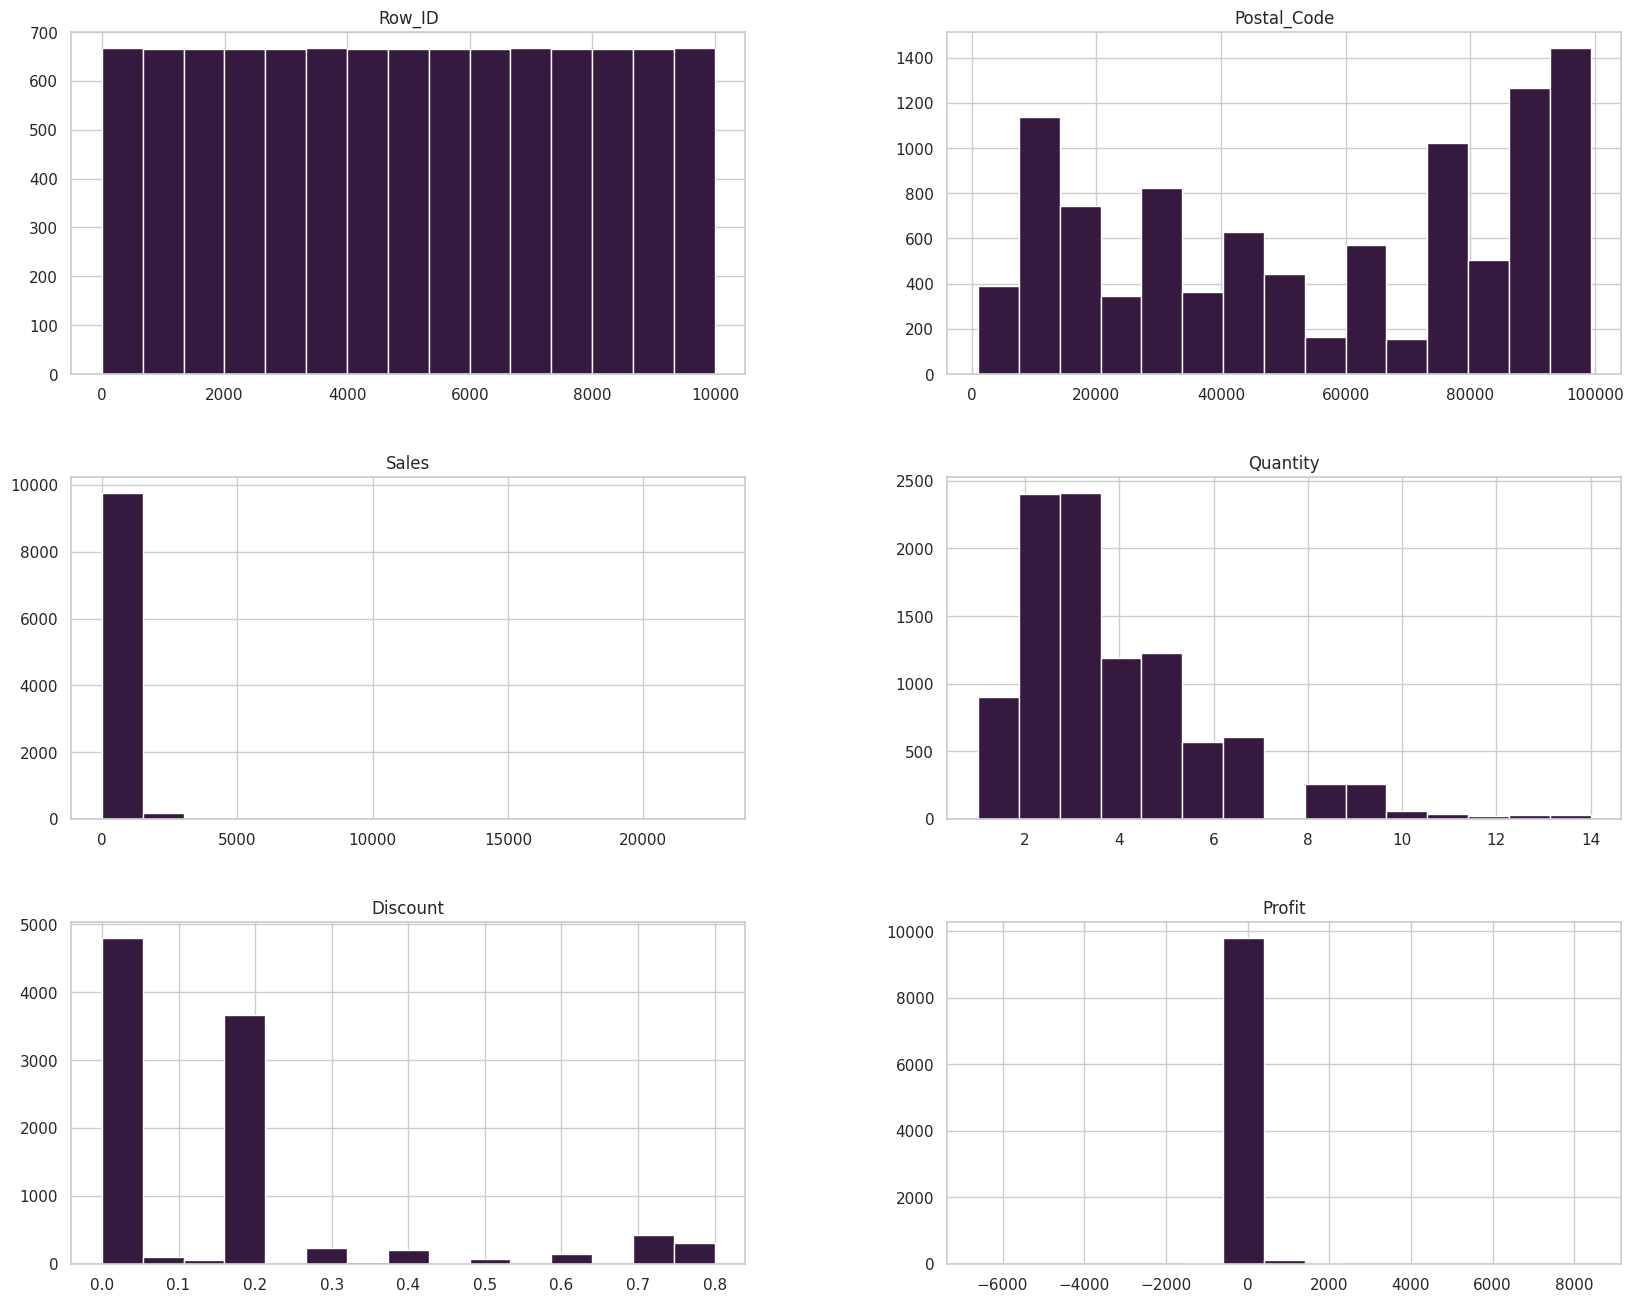

In [12]:
#. Plotando os histogramas das variáveis numéricas
df.hist(bins=15, figsize=(20,16));

- A distribuição de dados para as variáveis Sales e Profit indica que há valores muito discrepantes nos dados
- A distibuição para Discount também não é muito uniforme
- A Distribuição para a variável Quantity tem um perfil mais normal de distribuição.

Verificando a margem de lucro por Produto e Segmento

In [19]:
#. Descobrindo a margem de lucro por produto
productProfit = df.groupby('Product_Name').Profit.mean()
print(productProfit.sort_values(ascending=False))

Product_Name
Canon imageCLASS 2200 Advanced Copier                                    5039.985600
Canon imageCLASS MF7460 Monochrome Digital Laser Multifunction Copier    1995.990000
Ativa V4110MDD Micro-Cut Shredder                                        1886.473050
3D Systems Cube Printer, 2nd Generation, Magenta                         1858.985700
Zebra ZM400 Thermal Label Printer                                        1671.768000
                                                                            ...     
Zebra GK420t Direct Thermal/Thermal Transfer Printer                     -938.280000
Lexmark MX611dhe Monochrome Laser Printer                               -1147.493250
Cisco TelePresence System EX90 Videoconferencing Unit                   -1811.078400
Cubify CubeX 3D Printer Double Head Print                               -2959.990133
Cubify CubeX 3D Printer Triple Head Print                               -3839.990400
Name: Profit, Length: 1850, dtype: float64


In [20]:
#. Descobrindo a margem de lucro por Segmento
segmentProfit = df.groupby('Segment').Profit.mean()
print(segmentProfit.sort_values(ascending=False))

Segment
Home Office    33.818664
Corporate      30.456667
Consumer       25.836873
Name: Profit, dtype: float64
